# Machine Learning Model

## Objective

Train a machine learning model to predict the complaint category based on the complaint text.

In [1]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv("../data/complaints/bbmp_2024.csv")

df.head()

,Complaint ID,Category,Sub Category,Grievance Date,Ward Name,Grievance Status,Staff Remarks,Staff Name
0,20644646,Solid Waste (Garbage) Related,Garbage vehicle not arrived,2024-12-31 05:52:00.000000000,Manorayanapalya,Closed,Clear,Nagendra/JHI
1,20644640,Electrical,Street Light Not Working,2024-12-31 11:36:00.000000000,Basavanapura,Closed,Attended,Sachin Malagi/AE
2,20644639,Electrical,Street Light Not Working,2024-12-31 11:24:00.000000000,Maruthi Seva Nagar,Closed,Attended,Durga Prasad/AEE
3,20644638,Electrical,Street Light Not Working,2024-12-31 11:21:00.000000000,Aramane Nagar,Closed,Complaints Cleared,Suresh/AEE
4,20644637,Electrical,Street Light Not Working,2024-12-31 11:00:00.000000000,Vidyaranyapura,Closed,Resolved,Yelahanka AEE Electrical/AEE


In [3]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

df.columns

Index(['complaint_id', 'category', 'sub_category', 'grievance_date',
       'ward_name', 'grievance_status', 'staff_remarks', 'staff_name'],
      dtype='object')

In [4]:
df = df[["sub_category", "category"]]

df.head()

,sub_category,category
0,Garbage vehicle not arrived,Solid Waste (Garbage) Related
1,Street Light Not Working,Electrical
2,Street Light Not Working,Electrical
3,Street Light Not Working,Electrical
4,Street Light Not Working,Electrical


# Text Preprocessing for Machine Learning

## Objective

Prepare the complaint text for machine learning by cleaning and standardizing it.

In [5]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_text"] = df["sub_category"].apply(clean_text)

df[["sub_category", "clean_text"]].head()

,sub_category,clean_text
0,Garbage vehicle not arrived,garbage vehicle not arrived
1,Street Light Not Working,street light not working
2,Street Light Not Working,street light not working
3,Street Light Not Working,street light not working
4,Street Light Not Working,street light not working


## Observation

The complaint text has been converted to lowercase and cleaned by removing special characters and extra spaces.

# TF-IDF Vectorization

## Objective

Convert text into numerical vectors so that machine learning algorithms can process it.

In [7]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["clean_text"])

y = df["category"]

print(X.shape)

(207016, 302)


## Observation

The complaint text has been transformed into TF-IDF vectors, while the complaint category is stored as the target variable.

# Train-Test Split

## Objective

Split the dataset into training and testing sets to evaluate the model on unseen data.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(165612, 302)
(41404, 302)


## Observation

The dataset has been divided into:
- 80% Training Data
- 20% Testing Data

# Model Training

## Objective

Train a Logistic Regression model to classify complaint categories based on the complaint text.

In [9]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Observation

The Logistic Regression model has been trained successfully using the training dataset.

# Model Prediction

## Objective

Predict complaint categories for the testing dataset.

In [10]:
y_pred = model.predict(X_test)

y_pred[:10]

array(['Solid Waste (Garbage) Related', 'Road Maintenance(Engg)',
       'Electrical', 'Road Maintenance(Engg)', 'Health Dept',
       'veterinary', 'Electrical', 'Markets', 'Forest', 'Electrical'],
      dtype=object)

## Observation


The trained model predicts complaint categories for previously unseen complaint texts.

# Model Evaluation

## Objective

Evaluate the performance of the trained model.

In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9988889962322481


In [13]:
print(classification_report(y_test, y_pred))

c:\Users\ayush\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                               precision    recall  f1-score   support

                Advertisement       1.00      1.00      1.00       161
         BBMP Election Branch       1.00      0.40      0.57         5
               CORONA COVID19       1.00      0.92      0.96        12
                  Call Center       1.00      0.54      0.70        13
     E khata / Khata services       1.00      1.00      1.00        79
                    Education       0.00      0.00      0.00         5
                   Electrical       1.00      1.00      1.00     15015
                       Estate       0.00      0.00      0.00         7
                       Forest       1.00      1.00      1.00      2377
                  Health Dept       1.00      1.00      1.00      2999
               Indira Canteen       1.00      0.61      0.76        23
       Information Technology       1.00      1.00      1.00        26
                        Lakes       1.00      1.00      1.00       118
     

c:\Users\ayush\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ayush\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[  161     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0]
 [    0     2     0     0     0     0     0     0     0     3     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0]
 [    0     0    11     0     0     0     0     0     0     1     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0]
 [    0     0     0     7     0     0     0     0     0     0     0     0
      0     0     0     6     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0]
 [    0     0     0     0    79     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0]
 [    0     0     0     0     0    

## Observation

The evaluation metrics indicate how accurately the model predicts complaint categories.

Accuracy provides the overall performance, while the confusion matrix and classification report give detailed insights into class-wise predictions.

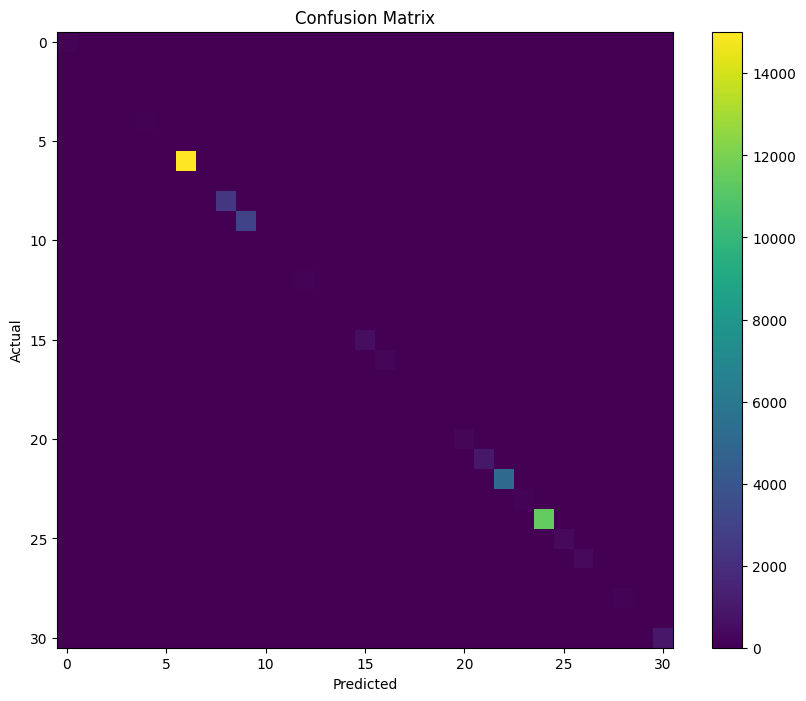

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Save Model

## Objective

Save the trained machine learning model and TF-IDF vectorizer for future predictions.

In [16]:
import pickle

pickle.dump(model, open("../models/model.pkl", "wb"))

pickle.dump(tfidf, open("../models/tfidf.pkl", "wb"))

print("Model Saved Successfully!")

Model Saved Successfully!
